In [4]:
import pandas as pd

In [5]:
df = pd.read_csv("customer_shopping_behavior.csv")

In [6]:
df.head(5)

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [7]:
df.shape

(3900, 18)

In [8]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3863.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.750065,25.351538
std,1125.977353,15.207589,23.685392,0.716983,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.800000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [9]:
df.describe()["Purchase Amount (USD)"]

count    3900.000000
mean       59.764359
std        23.685392
min        20.000000
25%        39.000000
50%        60.000000
75%        81.000000
max       100.000000
Name: Purchase Amount (USD), dtype: float64

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [11]:
df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

In [12]:
 df.groupby("Category")["Review Rating"].median()

Category
Accessories    3.8
Clothing       3.7
Footwear       3.8
Outerwear      3.8
Name: Review Rating, dtype: float64

In [13]:
df["Review Rating"] = df.groupby("Category")["Review Rating"].transform(lambda x: x.fillna(x.median()))

In [14]:
df.isnull().sum()

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

In [15]:
df.columns

Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Shipping Type',
       'Discount Applied', 'Promo Code Used', 'Previous Purchases',
       'Payment Method', 'Frequency of Purchases'],
      dtype='object')

In [16]:
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(" ","_")
df = df.rename(columns={"purchase_amount_(usd)":"purchase_amount"})

In [17]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='object')

#### create a column age_group

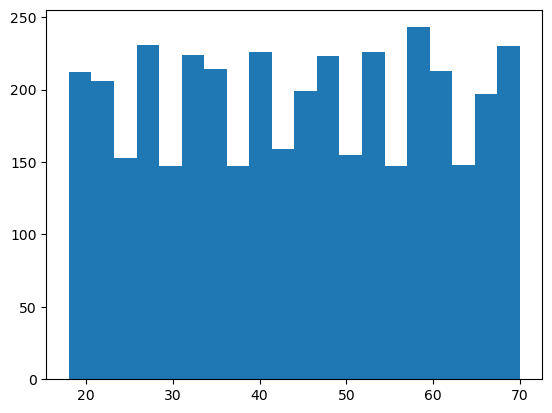

In [18]:
import matplotlib.pyplot as plt

plt.hist(df["age"], bins=20)
plt.show()

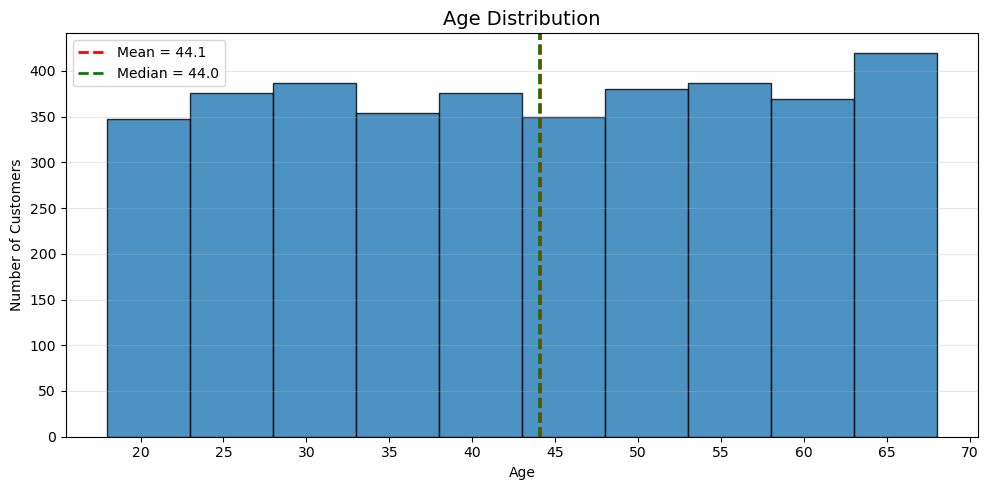

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(
    df["age"],
    bins=range(18, 72, 5),   # 5-year age groups
    edgecolor="black",
    alpha=0.8
)

# Add mean and median lines
mean_age = df["age"].mean()
median_age = df["age"].median()

plt.axvline(mean_age, color="red", linestyle="--", linewidth=2, label=f"Mean = {mean_age:.1f}")
plt.axvline(median_age, color="green", linestyle="--", linewidth=2, label=f"Median = {median_age:.1f}")

plt.title("Age Distribution", fontsize=14)
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.xticks(range(20, 71, 5))
plt.grid(axis="y", alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [20]:
df["age"].quantile([0, 0.25, 0.5, 0.75, 1])

0.00    18.0
0.25    31.0
0.50    44.0
0.75    57.0
1.00    70.0
Name: age, dtype: float64

In [21]:
labels = ["Young Adult", "Adult", "Middle-aged", "Senior"] 
df["age_group"] = pd.qcut(df["age"], q = 4 , labels = labels)

In [22]:
df[["age","age_group"]].head(10)

,age,age_group
0,55,Middle-aged
1,19,Young Adult
2,50,Middle-aged
3,21,Young Adult
4,45,Middle-aged
5,46,Middle-aged
6,63,Senior
7,27,Young Adult
8,26,Young Adult
9,57,Middle-aged


#### Create column purchase frequency days

In [23]:
frequency_mapping = {
    "Fortnightly" : 14,
    "Weekly" : 7,
    "Monthly" : 30,
    "Quarterly" : 90,
    "Annually" : 365,
    "BI-Weekly" : 14,
    "Every 3 Months" : 90
}

In [24]:
df["purchase_frequency_days"] = df["frequency_of_purchases"].map(frequency_mapping)

In [25]:
df[["frequency_of_purchases","purchase_frequency_days"]].head(10)

,frequency_of_purchases,purchase_frequency_days
0,Fortnightly,14.0
1,Fortnightly,14.0
2,Weekly,7.0
3,Weekly,7.0
4,Annually,365.0
5,Weekly,7.0
6,Quarterly,90.0
7,Weekly,7.0
8,Annually,365.0
9,Quarterly,90.0


In [26]:
df[["discount_applied","promo_code_used"]].head(10)

,discount_applied,promo_code_used
0,Yes,Yes
1,Yes,Yes
2,Yes,Yes
3,Yes,Yes
4,Yes,Yes
5,Yes,Yes
6,Yes,Yes
7,Yes,Yes
8,Yes,Yes
9,Yes,Yes


In [27]:
(df["discount_applied"] == df["promo_code_used"]).all()

np.True_

In [28]:
df = df.drop("promo_code_used", axis = 1)

In [29]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'previous_purchases', 'payment_method',
       'frequency_of_purchases', 'age_group', 'purchase_frequency_days'],
      dtype='object')

In [30]:
pip install pymysql sqlalchemy

In [ ]:
from sqlalchemy import create_engine

# MySQL connection details
username = "root"
password = "root"
host = "localhost"
port = "3306"
database = "customer_behaviour"

# Create SQLAlchemy engine
engine = create_engine(
    f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}"
)

# Write DataFrame to MySQL
df.to_sql(
    name="shopping_data",
    con=engine,
    if_exists="replace",   # or "append"
    index=False
)

# Read back a sample
sample_df = pd.read_sql(
    "SELECT * FROM shopping_data LIMIT 5",
    con=engine
)

print(sample_df)